# Q3: Geometric-SMOTE Region Benchmark

This notebook starts Question 3 from `manuscript/experiment_plan.md`:

> Does MIMIC compete with Geometric SMOTE on region-based oversampling?

Reusable experiment machinery lives in `src/mimic_experiments/q3_geometric_smote.py`. This notebook chooses parameters, calls that module, and displays saved result tables and plots.

In [9]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "mimic").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mimic import GenerationPolicy

from mimic_experiments.q3_geometric_smote import (
    Q3Config,
    load_q3_dataset,
    load_q3_result_tables,
    plot_q3_metric_comparison,
    print_progress_event,
    published_reference_table,
    q3_dataset_registry,
    q3_result_table_manifest,
    q3_result_table_paths,
    run_q3_benchmark,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experiment Controls

Use `RUN_PROFILE = "run_full"` to execute and save the repeated fivefold benchmark. Use `RUN_PROFILE = "view"` to skip fitting and regenerate displays from saved CSV tables.

In [10]:
# Dataset and run controls
DATASET = "wine"  # use a registry row number, or one of the ready keys: "pima", "iris", "wine"
RUN_PROFILE = "run_full"  # "run_full" or "view"
RANDOM_STATE = 0
N_REPEATS = 5
N_SPLITS = 5
N_JOBS = -1
ARTIFACT_DIR = str(PROJECT_ROOT / "manuscript" / "artifacts" / "q3_geometric_smote")
WORKER_THREADS = 1

# MIMIC controls
MIMIC_MODES = ("identity", "factorised")
MIMIC_CAPACITY_RUN_FULL = 0.25
MIMIC_FEATURE_N_JOBS = 1  # keep 1 when outer jobs parallelize work; increase when running one job at a time

# Classifier controls from the Geometric SMOTE paper
CLASSIFIERS = ("GBC", "LR")

# MIMIC generation policy controls
POLICY_METHOD = "smote"
POLICY_NEIGHBOUR_MODE = "normal"
POLICY_N_NEIGHBORS = 5
POLICY_LAMBDA_RANGE = (0.0, 1.0)

registry = q3_dataset_registry()
DATASET_KEY = registry.loc[DATASET, "key"] if isinstance(DATASET, int) else DATASET

config = Q3Config(
    dataset_key=DATASET_KEY,
    run_profile=RUN_PROFILE,
    random_state=RANDOM_STATE,
    n_repeats=N_REPEATS,
    n_splits=N_SPLITS,
    n_jobs=N_JOBS,
    artifact_dir=ARTIFACT_DIR,
    worker_threads=WORKER_THREADS,
    classifiers=CLASSIFIERS,
    mimic_modes=MIMIC_MODES,
    mimic_capacity_run_full=MIMIC_CAPACITY_RUN_FULL,
    mimic_feature_n_jobs=MIMIC_FEATURE_N_JOBS,
    policy=GenerationPolicy(
        method=POLICY_METHOD,
        neighbour_mode=POLICY_NEIGHBOUR_MODE,
        n_neighbors=POLICY_N_NEIGHBORS,
        lambda_range=POLICY_LAMBDA_RANGE,
    ),
)
config


Q3Config(dataset_key='wine', run_profile='run_full', random_state=0, n_repeats=5, n_splits=5, classifiers=('GBC', 'LR'), mimic_modes=('identity', 'factorised'), mimic_capacity_run_full=0.25, artifact_dir='/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/MIMIC/manuscript/artifacts/q3_geometric_smote', n_jobs=-1, worker_threads=1, mimic_feature_n_jobs=1, policy=GenerationPolicy(method='smote', neighbour_mode='normal', n_neighbors=5, lambda_range=(0.0, 1.0), class_conditioned=False, cluster_conditioned=False))

## Dataset Registry

The registry records the dataset distributions reported by the Geometric SMOTE paper and which exact loaders are currently available.

In [11]:
display(
    q3_dataset_registry(
        artifact_dir=ARTIFACT_DIR,
        run_profile=RUN_PROFILE,
        mimic_modes=MIMIC_MODES,
        mimic_capacity=config.mimic_capacity,
        policy=config.policy,
        random_state=RANDOM_STATE,
    )
)


,key,dataset,features,instances,minority,majority,ir,status,experiment
0,breast,Breast,9,106,36,70,1.94,optional: exact UCI source mapping needed,not run
1,ecoli,Ecoli,7,336,52,284,5.46,optional: exact class mapping needed,not run
2,eucalyptus,Eucalyptus,8,642,98,544,5.55,optional: source needed,not run
3,glass,Glass,9,214,70,144,2.06,optional: exact class mapping needed,not run
4,haberman,Haberman,3,306,81,225,2.78,optional: exact class mapping needed,not run
5,heart,Heart,13,270,120,150,1.25,optional: exact source mapping needed,not run
6,iris,Iris,4,150,50,100,2.00,ready: sklearn iris class 0 vs rest,not run
7,libra,Libra,90,360,72,288,4.00,optional: exact class mapping needed,not run
8,liver,Liver,6,345,145,200,1.38,optional: exact source mapping needed,not run
9,pima,Pima,8,768,268,500,1.87,ready: OpenML data_id=37,not run


## Published Reference Table

In [12]:
display(published_reference_table())


,dataset,classifier,metric,no_oversampling,smote,borderline_smote1,borderline_smote2,adasyn,geometric_smote,published_best_method,published_best_value
0,Breast,GBC,F,0.700,0.715,0.727,0.705,0.673,0.722,Borderline SMOTE1,0.727
1,Breast,GBC,G,0.770,0.780,0.795,0.774,0.748,0.789,Borderline SMOTE1,0.795
2,Breast,GBC,AUC,0.867,0.867,0.867,0.869,0.858,0.874,Geometric SMOTE,0.874
3,Breast,LR,F,0.687,0.732,0.747,0.734,0.730,0.748,Geometric SMOTE,0.748
4,Breast,LR,G,0.752,0.799,0.812,0.803,0.798,0.812,Borderline SMOTE1 / Geometric SMOTE,0.812
...,...,...,...,...,...,...,...,...,...,...,...
73,Wine,GBC,G,0.925,0.923,0.927,0.922,0.898,0.943,Geometric SMOTE,0.943
74,Wine,GBC,AUC,0.979,0.978,0.978,0.975,0.965,0.986,Geometric SMOTE,0.986
75,Wine,LR,F,0.928,0.935,0.939,0.937,0.898,0.938,Borderline SMOTE1,0.939
76,Wine,LR,G,0.941,0.947,0.951,0.950,0.918,0.951,Borderline SMOTE1 / Geometric SMOTE,0.951


## Load Dataset

In [13]:
if config.should_run_experiment:
    df = load_q3_dataset(config)
    display(df.head())
    display(df["label"].value_counts().rename_axis("label").to_frame("count"))
else:
    df = None
    print("RUN_PROFILE=view: skipping dataset load; saved CSV tables will be loaded below.")


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,majority
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,majority
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,majority
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,majority
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,majority


,count
label,
majority,107
minority,71


## Run Or Reuse Q3 Benchmark

`run_full` runs MIMIC oversampling inside each training fold, evaluates the GBC/LR protocol, and saves row-level and summary CSVs. `view` skips fitting and uses filenames reconstructed from `DATASET` and the config.

In [14]:
if config.should_run_experiment:
    run_q3_benchmark(df, config, progress=print_progress_event)
else:
    print("RUN_PROFILE=view: skipping experiment run.")

print("Q3 result table filenames:")
for table, path in q3_result_table_paths(config).items():
    print(f"{table}: {path}")
display(q3_result_table_manifest(config))


Starting Q3 jobs: 0/250 complete (36 worker(s))
Completed job 1/250, elapsed 5s, ETA 19m 22s
Completed job 2/250, elapsed 5s, ETA 10m 17s
Completed job 3/250, elapsed 5s, ETA 6m 55s
Completed job 4/250, elapsed 5s, ETA 5m 24s
Completed job 5/250, elapsed 6s, ETA 4m 34s
Completed job 6/250, elapsed 6s, ETA 3m 48s
Completed job 7/250, elapsed 6s, ETA 3m 17s
Completed job 8/250, elapsed 6s, ETA 2m 55s
Completed job 9/250, elapsed 6s, ETA 2m 38s
Completed job 10/250, elapsed 6s, ETA 2m 24s
Completed job 11/250, elapsed 6s, ETA 2m 12s
Completed job 12/250, elapsed 6s, ETA 2m 02s
Completed job 13/250, elapsed 6s, ETA 1m 53s
Completed job 14/250, elapsed 6s, ETA 1m 47s
Completed job 15/250, elapsed 6s, ETA 1m 39s
Completed job 16/250, elapsed 6s, ETA 1m 33s
Completed job 17/250, elapsed 7s, ETA 1m 31s
Completed job 18/250, elapsed 7s, ETA 1m 26s
Completed job 19/250, elapsed 7s, ETA 1m 22s
Completed job 20/250, elapsed 7s, ETA 1m 18s
Completed job 21/250, elapsed 7s, ETA 1m 16s
Completed job 

,table,path
0,fold_results,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
1,summary,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
2,manuscript,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...


## Load Saved Result Tables

Performance summaries and plots below read from the CSV tables saved by the benchmark.

In [15]:
fold_results, q3_summary, manuscript_table = load_q3_result_tables(config)

display(q3_summary)
display(fold_results.head())
display(manuscript_table)


,dataset_key,dataset,run_profile,mimic_mode,method,classifier,classifier_params,metric,value,std,n_folds,artifact_dir
0,wine,Wine,run_full,factorised,MIMIC-factorised,GBC,"{'max_depth': 5, 'n_estimators': 100}",AUC,0.934294,0.045073,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
1,wine,Wine,run_full,factorised,MIMIC-factorised,GBC,"{'max_depth': 5, 'n_estimators': 50}",F,0.896397,0.062572,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
2,wine,Wine,run_full,factorised,MIMIC-factorised,GBC,"{'max_depth': 8, 'n_estimators': 100}",G,0.912499,0.053451,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
3,wine,Wine,run_full,factorised,MIMIC-factorised,LR,"{'max_iter': 1000, 'solver': 'lbfgs'}",AUC,0.999072,0.001996,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
4,wine,Wine,run_full,factorised,MIMIC-factorised,LR,"{'max_iter': 1000, 'solver': 'lbfgs'}",F,0.973225,0.020233,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
5,wine,Wine,run_full,factorised,MIMIC-factorised,LR,"{'max_iter': 1000, 'solver': 'lbfgs'}",G,0.977016,0.017654,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
6,wine,Wine,run_full,identity,MIMIC-identity,GBC,"{'max_depth': 5, 'n_estimators': 100}",AUC,0.939617,0.041241,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
7,wine,Wine,run_full,identity,MIMIC-identity,GBC,"{'max_depth': 5, 'n_estimators': 100}",F,0.904773,0.059250,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
8,wine,Wine,run_full,identity,MIMIC-identity,GBC,"{'max_depth': 5, 'n_estimators': 100}",G,0.919028,0.052003,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
9,wine,Wine,run_full,identity,MIMIC-identity,LR,"{'max_iter': 1000, 'solver': 'lbfgs'}",AUC,0.998275,0.003266,25,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...


,dataset_key,repeat,fold,mimic_mode,classifier,classifier_params,n_train,n_test,n_generated,f_measure,g_mean,auc,specificity,tp,fp,tn,fn
0,wine,1,1,identity,LR,"{'max_iter': 1000, 'solver': 'lbfgs'}",142,36,28,0.965517,0.977008,1.000000,0.954545,14,1,21,0
1,wine,1,4,identity,GBC,"{'max_depth': 8, 'n_estimators': 50}",143,35,29,0.888889,0.903508,0.921769,0.952381,12,1,20,2
2,wine,1,1,identity,GBC,"{'max_depth': 5, 'n_estimators': 50}",142,36,28,0.962963,0.963624,0.962662,1.000000,13,0,22,1
3,wine,1,2,identity,GBC,"{'max_depth': 5, 'n_estimators': 50}",142,36,28,0.933333,0.953463,0.954545,0.909091,14,2,20,0
4,wine,1,1,identity,GBC,"{'max_depth': 8, 'n_estimators': 50}",142,36,28,0.962963,0.963624,0.962662,1.000000,13,0,22,1


,dataset,classifier,metric,no_oversampling,smote,borderline_smote1,borderline_smote2,adasyn,geometric_smote,published_best_method,published_best_value,mimic_identity,mimic_identity_delta_vs_best,mimic_factorised,mimic_factorised_delta_vs_best
0,Wine,GBC,F,0.911,0.908,0.912,0.907,0.875,0.933,Geometric SMOTE,0.933,0.904773,-0.028227,0.896397,-0.036603
1,Wine,GBC,G,0.925,0.923,0.927,0.922,0.898,0.943,Geometric SMOTE,0.943,0.919028,-0.023972,0.912499,-0.030501
2,Wine,GBC,AUC,0.979,0.978,0.978,0.975,0.965,0.986,Geometric SMOTE,0.986,0.939617,-0.046383,0.934294,-0.051706
3,Wine,LR,F,0.928,0.935,0.939,0.937,0.898,0.938,Borderline SMOTE1,0.939,0.968985,0.029985,0.973225,0.034225
4,Wine,LR,G,0.941,0.947,0.951,0.950,0.918,0.951,Borderline SMOTE1 / Geometric SMOTE,0.951,0.973189,0.022189,0.977016,0.026016
5,Wine,LR,AUC,0.992,0.992,0.991,0.992,0.985,0.993,Geometric SMOTE,0.993,0.998275,0.005275,0.999072,0.006072


## Plot Metric Comparison

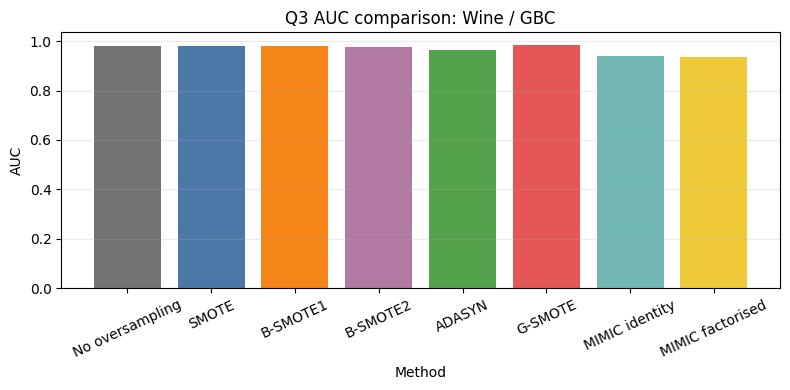

In [18]:
fig, ax = plot_q3_metric_comparison(manuscript_table, classifier="GBC", metric="AUC")
